En este archivo Notebook realizo diferentes implementaciones del proyecto para poder ejecutarlas por bloques y obtener un resultado visual

In [13]:
# Añadimos todas las librerias necesarias
import oracledb as oracledb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Creación de la conexión a la base de datos

In [14]:
# Crear el DSN usando la IP remota
dsn = oracledb.makedsn("afrodita.lcc.uma.es", 1521, sid="APOLO")

# Conectarse
conn = oracledb.connect(user="tfm_puertas", password="JCGRmlbEsc", dsn=dsn)

# Ejecutar consulta
cur = conn.cursor()
cur.execute("select distinct nombreasignatura from v_calificaciones")
for row in cur:
    print(row)

cur.close()

('Bases de Datos',)
('Estructura de Datos',)
('Ingeniería y Ciencia de Datos II',)
('Industrialización y Despliegue de Sistemas loT',)
('Planificación de Proyectos y Análisis de Riesgos',)
('Control Automático',)
('Programación de Videojuegos',)
('Diseño de Sistemas Operativos',)
('Bioquímica Estructural',)
('Física II',)
('Laboratorio de Computación Científica',)
('Administración de Bases de Datos',)
('Seguridad en Sistemas Industriales y Ciberfísicos',)
('Visión por Computador',)
('Sistemas de Información Empresarial',)
('Arquitecturas Paralelas',)
('Programación Distribuida',)
('Ingeniería del Software Avanzada',)
('Álgebra Lineal y Geometría',)
('Análisis Matemático III',)
('Telemedicina',)
('Inferencia Estadística',)
('Geometría Diferencial Global de Superficies',)
('Teoría de Autómatas y Lenguajes Formales',)
('Desarrollo de Aplicaciones en la Nube',)
('Sistemas de Información para Internet',)
('Diseño y Evaluación de Infraestructuras Informáticas',)
('Cognición y Comunicación en

PARA LA REUNIÓN, POR QUÉ LA MEDIA ESTABA DANDO PROBLEMAS

In [15]:
cur = conn.cursor()
cur.execute("""
            SELECT nombreasignatura, NUM_CALIFICACIÓN, cursoacadémico
            FROM v_calificaciones
            WHERE codigoalum = 'B30A2DCB567D8E3120A3E33582F98B90' AND calificación NOT IN ('NO PRESENTADO', 'SUSPENSO')
            """)
for row in cur:
    print(row)

('Teoría de Autómatas y Lenguajes Formales', '7', '2018-19')


Hay alumnos en la base de datos que apenas tienen asignaturas aprobadas, ya sea porque es asi o porque la información no está completa, por lo que los voy a descartar de la comprobación

Función que calcula la nota media ponderada.

Nota media ponderada: Media de todas las asignaturas aprobadas por el número de créditos que valen, dividido entre el total de créditos de la titulación

In [17]:
def calcular_media_ponderada(conn, codigo_alumno, curso_max):
    with conn.cursor() as cur: 
        cur.execute("""
            SELECT 
                AVG(TO_NUMBER(NUM_CALIFICACIÓN)) AS media_aprobadas,
                COUNT(*) AS asignaturas_aprobadas,
                SUM(CREDITOS) AS creditos_aprobados
            FROM v_calificaciones
            WHERE CODIGOALUM = :codigo
            AND CALIFICACIÓN NOT IN ('NO PRESENTADO', 'SUSPENSO')
            AND TO_NUMBER(SUBSTR(CURSOACADÉMICO, 1, 4)) < TO_NUMBER(SUBSTR(:curso_inicio , 1, 4))
        """, codigo=codigo_alumno, curso_inicio=curso_max[:4])

        resultado = cur.fetchone() #Como esperamos solo un resultado, uso fetchone
        media, aprobadas, creditos = resultado

        if media is None or aprobadas == 0:
            return (None, 0)  # Evitamos división por cero o falta de datos

        ponderada = (media * creditos) / 240
        return (round(ponderada, 2), aprobadas) #CAMBIO: Devuelvo también la cantidad de aprobadas
    
calcular_media_ponderada(conn, '0208F18506E41D3F29A4CAAD842FD0FA','2020-21')


(1.57, 11)

Dada una asignatura, obtener todos los alumnos que la han cursado, y el curso académico en el que lo hicieron

In [7]:
def obtener_alumnos_matriculados(conn, nombre_asignatura):
    with conn.cursor() as cur:
        cur.execute("""
            SELECT DISTINCT CODIGOALUM, CURSOACADÉMICO
            FROM v_calificaciones
            WHERE NOMBREASIGNATURA = :asignatura
        """, asignatura=nombre_asignatura)

        return cur.fetchall()
        
obtener_alumnos_matriculados(conn, 'Visión por Computador')


[('E7AC1E0B6F38D865A51141CEAA6AABDC', '2018-19'),
 ('0154E5C78A6179BDB090C06DEC095A17', '2018-19'),
 ('7334688E1698AECCCB5C2693A55E91DB', '2019-20'),
 ('09D3DA93C1195F9337C98092057E86BE', '2019-20'),
 ('56D2035062EF09C99B875AF14B6DBAEF', '2019-20'),
 ('F2D77DDA93F07980CDAFA4FC9B49B81F', '2020-21'),
 ('E475FCF6F6FB2F4200647487CBBA367B', '2020-21'),
 ('E8C0BD34336D34FB3D50886305A9DE12', '2020-21'),
 ('592AEBD3C172B1FF1B0017D1296ED7E8', '2021-22'),
 ('9475ED7552FA67FD81C807CACB4497F4', '2021-22'),
 ('B532D6CA33EAE40DB254D225231E4986', '2022-23'),
 ('B4A95BD04DD3E641CBDF84E3F3416C64', '2022-23'),
 ('8FAB2C4EDCA1484446405F73B2EC2026', '2022-23'),
 ('7114F27ECC34C1E75F8557E099343544', '2020-21'),
 ('6D4F20745BAB50857886AAD4AFD339D5', '2021-22'),
 ('47BA4947D4B7CE8520F27723ABC03B29', '2020-21'),
 ('43ECD972302EE21A6B0ECCBB67940670', '2018-19'),
 ('D7F78EB38BBCCC219CC12770E0CCD213', '2018-19'),
 ('8E14F1B5DE2DEEC5FED6D376A2A53E72', '2019-20'),
 ('E08B5D4B37BF613FDA0E9D477207702C', '2019-20'),


Calcular nota de corte de cada año

Nota de corte: La nota media ponderada más baja que está matriculado en la asignatura hasta el año anterior de la matrícula

In [11]:
def calcular_nota_corte(conn, nombre_asignatura):
    # 1. Obtener alumnos + curso académico donde cursaron esa asignatura
    alumnos_con_curso = obtener_alumnos_matriculados(conn, nombre_asignatura)

    # 2. Agrupar alumnos por curso académico
    cursos = {}
    for codigo_alum, curso_acad in alumnos_con_curso:
        cursos.setdefault(curso_acad, []).append(codigo_alum)

    # 3. Para cada curso, calcular la nota de corte
    nota_corte_por_año = {}

    for curso_acad, codigos_alumnos in cursos.items():
        medias = []
        for codigo_alum in codigos_alumnos:
            resultado = calcular_media_ponderada(conn, codigo_alum, curso_acad)
            if resultado:
                media, aprobadas = resultado
                if media is not None and aprobadas > 11:
                    print(media, ',', codigo_alum)
                    medias.append(media)
        if medias:
            nota_corte_por_año[curso_acad] = min(medias)

    return nota_corte_por_año  # Dict: { "2018-19": 6.25, "2019-20": 5.8, ... }

calcular_nota_corte(conn, 'Visión por Computador')


3.0 , F2D77DDA93F07980CDAFA4FC9B49B81F
1.9 , E475FCF6F6FB2F4200647487CBBA367B
4.33 , E8C0BD34336D34FB3D50886305A9DE12
3.55 , 7114F27ECC34C1E75F8557E099343544
4.58 , 47BA4947D4B7CE8520F27723ABC03B29
2.5 , E0CEE1184B8A37EA15EA3DE72608EF58
1.77 , 8CE2843DF91278BE99E511E7859CE7A5
3.38 , 6D264FD7B2CB93D4B5E277E0DA69E125
3.05 , 3CCF328E18D2EF11DE8CE82454681648
3.4 , 7B1B567DCD59BDCAEE164235D3791E6E
4.2 , 2C5050CFC3402E9E9F528F12BA3CA1DD
2.45 , DD64D12477DC83CBDA4C1529F9D40EB4
2.62 , 38A8ABF79A5FA8A18750C4AB49FB692A
2.25 , 99ADFA8491D3BEA5CB73B7ACB4E943F3
2.75 , 4E0181177FE280B6C308109AFB23A4C6
3.33 , 8DD502A15AD2AC6D39E209C7BEE16A71
4.67 , BC35AEBDEE0821C454655C8B0A9AA47B
2.95 , 6D4F5913DFB1CDE3B676B49FE63435C2
3.9 , 9DE40F9A3BE1AD331661249791118E51
3.55 , 7CA387F218D978C15869E4CAC8D47809
3.17 , 8A877E0C3DD4CA42A515BAD4E8570352
3.3 , E684F6A41A033ECA6CEA04E644077F57
3.5 , F6EA716D200E74972F4FD3BD975C55DC
2.6 , 9C4267569C9FF29620C3084FAB122899
2.2 , CA6E40A757730BEB921CBD6B91EAB2C3
2.17 , EE3

{'2020-21': 1.77, '2021-22': 2.33, '2022-23': 2.12}

Cálculo de la probabilidad de entrada: Dada la nota de corte de cada año, el porcentaje de años en los que habría entrado en la asignatura

In [32]:
def calcular_probabilidad_entrada(conn, nombre_asignatura, codigo_alumno):
    # Obtener las notas de corte por año
    notas_corte = calcular_nota_corte(conn, nombre_asignatura)
    print(notas_corte)

    if not notas_corte:
        return 0.0  # No hay base para calcular probabilidad

    total = 0
    supera = 0

    media_alumno, aprobadas = calcular_media_ponderada(conn, codigo_alumno, '2022-23')
    print(media_alumno)
    #media_alumno = 0.15
    for curso_acad, nota_corte in notas_corte.items():
        
        if media_alumno is not None:
            total += 1
            if media_alumno > nota_corte:
                supera += 1

    if total == 0:
        return 0.0  # El alumno no tiene historial válido

    probabilidad = (supera / total) * 100
    return round(probabilidad, 2)

calcular_probabilidad_entrada(conn, 'Visión por Computador', '0208F18506E41D3F29A4CAAD842FD0FA')


1.9 , B6F470F0C52335228D8AA2A351BF94D9
3.0 , F2D77DDA93F07980CDAFA4FC9B49B81F
1.9 , E475FCF6F6FB2F4200647487CBBA367B
4.32 , E8C0BD34336D34FB3D50886305A9DE12
3.55 , 7114F27ECC34C1E75F8557E099343544
4.58 , 47BA4947D4B7CE8520F27723ABC03B29
2.5 , E0CEE1184B8A37EA15EA3DE72608EF58
1.77 , 8CE2843DF91278BE99E511E7859CE7A5
3.38 , 6D264FD7B2CB93D4B5E277E0DA69E125
3.05 , 3CCF328E18D2EF11DE8CE82454681648
3.4 , 7B1B567DCD59BDCAEE164235D3791E6E
4.2 , 2C5050CFC3402E9E9F528F12BA3CA1DD
2.45 , DD64D12477DC83CBDA4C1529F9D40EB4
2.62 , 38A8ABF79A5FA8A18750C4AB49FB692A
2.25 , 99ADFA8491D3BEA5CB73B7ACB4E943F3
2.75 , 4E0181177FE280B6C308109AFB23A4C6
3.33 , 8DD502A15AD2AC6D39E209C7BEE16A71
4.67 , BC35AEBDEE0821C454655C8B0A9AA47B
2.95 , 6D4F5913DFB1CDE3B676B49FE63435C2
3.9 , 9DE40F9A3BE1AD331661249791118E51
3.55 , 7CA387F218D978C15869E4CAC8D47809
3.17 , 8A877E0C3DD4CA42A515BAD4E8570352
3.3 , E684F6A41A033ECA6CEA04E644077F57
3.5 , F6EA716D200E74972F4FD3BD975C55DC
2.6 , 9C4267569C9FF29620C3084FAB122899
2.2 , CA6E

100.0

Creo el cluster y leo la base de datos del csv para agilizar procesos. Entreno el cluster con una matriz de alumnos x asignaturas

In [ ]:
# Suponemos que tienes un DataFrame con columnas: ['CODIGOALUM', 'NOMBREASIGNATURA', 'NUM_CALIFICACIÓN']
df = pd.read_csv("data.csv")
def entrenar_clustering(df, n_clusters=12):
    # Crear matriz alumno-asignatura
    matriz = df.pivot_table(index='CODIGOALUM', columns='NOMBREASIGNATURA', values='NUM_CALIFICACIÓN')
    matriz = matriz.fillna(0)  #Para evitar valores NaN
    
    scaler = StandardScaler()
    matriz_escalada = scaler.fit_transform(matriz)
    
    modelo = KMeans(n_clusters=n_clusters, random_state=42)
    modelo.fit(matriz_escalada)
    
    # Añadir etiquetas de cluster
    df_clusters = pd.DataFrame(matriz.index, columns=['CODIGOALUM'])
    df_clusters['cluster'] = modelo.labels_
    
    return modelo, scaler, matriz, df_clusters

Busco el cluster al que se asemeja el alumno, y ahí comparo las notas para ver la similitud

In [20]:
def predecir_afinidad_cluster(alumno_id, asignatura, modelo, scaler, matriz, df_clusters, df_original):
    if alumno_id not in matriz.index or asignatura not in matriz.columns:
        return None
    
    alumno_vector = scaler.transform(matriz.loc[[alumno_id]])
    cluster_id = modelo.predict(alumno_vector)[0]
    
    # Alumnos en ese cluster
    alumnos_similares = df_clusters[df_clusters['cluster'] == cluster_id]['CODIGOALUM']
    
    # Notas en la asignatura de ese grupo
    notas = df_original[
        (df_original['CODIGOALUM'].isin(alumnos_similares)) &
        (df_original['NOMBREASIGNATURA'] == asignatura) &
        (df_original['NUM_CALIFICACIÓN'].notnull())
    ]['NUM_CALIFICACIÓN'].astype(float)
    
    if notas.empty:
        return 0.0
    
    return round(notas.mean() / 10, 3)


In [ ]:
modelo, scaler, matriz, df_clusters = entrenar_clustering(df)
afinidad = predecir_afinidad_cluster('0208F18506E41D3F29A4CAAD842FD0FA', 'Desarrollo de Software Crítico', modelo, scaler, matriz, df_clusters, df)
print(f"Afinidad estimada: {afinidad}")

Afinidad estimada: 0.566
(2852, 184)


In [8]:
#Cierre de conexión
conn.close()

In [ ]:
# Función para construir la matriz de alumnos
def construir_matriz(df):
    matriz = df.pivot_table(index='CODIGOALUM', columns='NOMBREASIGNATURA', values='NUM_CALIFICACIÓN')
    matriz = matriz.fillna(0)
    return matriz

# Método del codo
def metodo_del_codo(matriz, max_k=10):
    scaler = StandardScaler()
    matriz_escalada = scaler.fit_transform(matriz)
    
    inercia = []
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(matriz_escalada)
        inercia.append(kmeans.inertia_)
    
    # Graficar el codo
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), inercia, marker='o')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia (WCSS)')
    plt.title('Método del Codo')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.show()
    plt.savefig()

    return inercia  # Por si quieres usarla luego


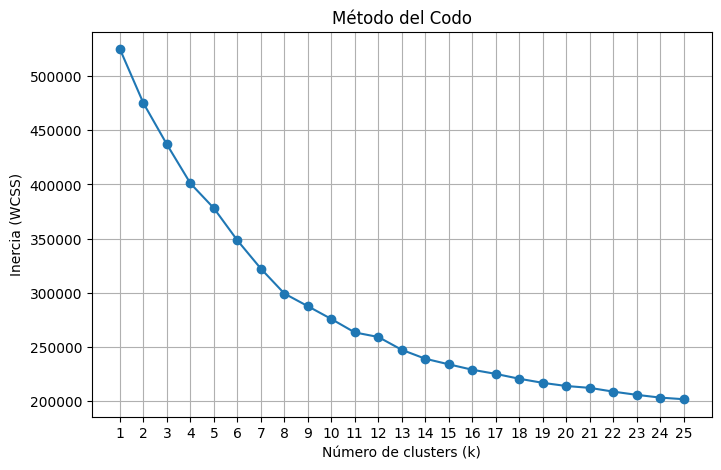

[524767.9999999995,
 474959.9822138557,
 436871.31257614587,
 400991.4151319673,
 378047.13738093665,
 348393.9523583652,
 322315.03230254515,
 299345.47000196157,
 287665.32335647685,
 275868.7602534302,
 263459.75116747024,
 259260.63812038387,
 247426.68227083643,
 239207.65874609555,
 234040.37721570936,
 229059.3794057828,
 225219.96759585052,
 220741.34732522146,
 216964.41714853456,
 214052.58335602313,
 212324.9266775453,
 208860.5249795756,
 205898.45490318484,
 203351.75293992067,
 201842.23665689613]

In [27]:
matriz = construir_matriz(df)
metodo_del_codo(matriz, max_k=25)